# ***Feature/Threshold Analysis and Ablations***

In [1]:
import numpy as np
import joblib
from src.analyzing import *

# **Part 1a: Feature Interpretation**

In [2]:
lr_2008_oop = joblib.load("results/models/lr_2008_High_OOP_Burden.joblib")
lr_2008_payer = joblib.load("results/models/lr_2008_High_Payer_Cost.joblib")
lr_2009_oop = joblib.load("results/models/lr_2009_High_OOP_Burden.joblib")
lr_2009_payer = joblib.load("results/models/lr_2009_High_Payer_Cost.joblib")
lr_2010_oop = joblib.load("results/models/lr_2010_High_OOP_Burden.joblib")
lr_2010_payer = joblib.load("results/models/lr_2010_High_Payer_Cost.joblib")

rf_2008_oop = joblib.load("results/models/rf_2008_High_OOP_Burden.joblib")
rf_2008_payer = joblib.load("results/models/rf_2008_High_Payer_Cost.joblib")
rf_2009_oop = joblib.load("results/models/rf_2009_High_OOP_Burden.joblib")
rf_2009_payer = joblib.load("results/models/rf_2009_High_Payer_Cost.joblib")
rf_2010_oop = joblib.load("results/models/rf_2010_High_OOP_Burden.joblib")
rf_2010_payer = joblib.load("results/models/rf_2010_High_Payer_Cost.joblib")

xgb_2008_oop = joblib.load("results/models/xgb_2008_High_OOP_Burden.joblib")
xgb_2008_payer = joblib.load("results/models/xgb_2008_High_Payer_Cost.joblib")
xgb_2009_oop = joblib.load("results/models/xgb_2009_High_OOP_Burden.joblib")
xgb_2009_payer = joblib.load("results/models/xgb_2009_High_Payer_Cost.joblib")
xgb_2010_oop = joblib.load("results/models/xgb_2010_High_OOP_Burden.joblib")
xgb_2010_payer = joblib.load("results/models/xgb_2010_High_Payer_Cost.joblib")

In [3]:
models = {
    "lr": {
        (2008, "High_OOP_Burden"): lr_2008_oop,
        (2008, "High_Payer_Cost"): lr_2008_payer,
        (2009, "High_OOP_Burden"): lr_2009_oop,
        (2009, "High_Payer_Cost"): lr_2009_payer,
        (2010, "High_OOP_Burden"): lr_2010_oop,
        (2010, "High_Payer_Cost"): lr_2010_payer,
    },
    "rf": {
        (2008, "High_OOP_Burden"): rf_2008_oop,
        (2008, "High_Payer_Cost"): rf_2008_payer,
        (2009, "High_OOP_Burden"): rf_2009_oop,
        (2009, "High_Payer_Cost"): rf_2009_payer,
        (2010, "High_OOP_Burden"): rf_2010_oop,
        (2010, "High_Payer_Cost"): rf_2010_payer,
    },
    "xgb": {
        (2008, "High_OOP_Burden"): xgb_2008_oop,
        (2008, "High_Payer_Cost"): xgb_2008_payer,
        (2009, "High_OOP_Burden"): xgb_2009_oop,
        (2009, "High_Payer_Cost"): xgb_2009_payer,
        (2010, "High_OOP_Burden"): xgb_2010_oop,
        (2010, "High_Payer_Cost"): xgb_2010_payer,
    }
}

In [4]:
importance_results = {"lr": {}, "rf":{}, "xgb":{}}

for model_type, model_group in models.items():
    for (year, target), model in model_group.items():
        feature_path = f"results/feature_names/" f"{model_type}_{year}_{target}_features.csv"
        importance_results[model_type][(year, target)] = extract_feature_importance(model, model_type, feature_path = feature_path)

In [5]:
importance_results["lr"][(2009, "High_Payer_Cost")]

{'positive':     index             feature  coefficient  odds_ratio  importance
 0     294  BENE_COUNTY_CD_881     2.102391    8.185720    2.102391
 1      99  BENE_COUNTY_CD_251     1.769069    5.865390    1.769069
 2     196  BENE_COUNTY_CD_651     1.674846    5.337972    1.674846
 3     212  BENE_COUNTY_CD_702     1.346505    3.843967    1.346505
 4     218  BENE_COUNTY_CD_722     1.304786    3.686900    1.304786
 5     242  BENE_COUNTY_CD_783     1.287202    3.622637    1.287202
 6     324  BENE_COUNTY_CD_945     1.230080    3.421502    1.230080
 7     232  BENE_COUNTY_CD_756     1.205345    3.337910    1.205345
 8     355  BENE_COUNTY_CD_987     1.152846    3.167193    1.152846
 9     267  BENE_COUNTY_CD_834     1.146973    3.148647    1.146973
 10    164  BENE_COUNTY_CD_542     1.069661    2.914391    1.069661
 11    234  BENE_COUNTY_CD_758     1.035816    2.817403    1.035816
 12    266  BENE_COUNTY_CD_832     1.035186    2.815629    1.035186
 13    352  BENE_COUNTY_CD_984     1

In [6]:
importance_results["rf"][(2009, "High_Payer_Cost")]

{'importance':      index                              feature  importance
 0       39    2008_total_carrier_insurance_cost    0.063693
 1       27              2008_num_carrier_claims    0.056207
 2       41  2008_total_carrier_beneficiary_cost    0.053097
 3       37  2008_avg_carrier_reimb_allowed_diff    0.034383
 4       38      2008_avg_carrier_insurance_cost    0.034098
 ..     ...                                  ...         ...
 419    281                   BENE_COUNTY_CD_862    0.000000
 420    282                   BENE_COUNTY_CD_867    0.000000
 421    284                   BENE_COUNTY_CD_871    0.000000
 422    285                   BENE_COUNTY_CD_872    0.000000
 423    212                   BENE_COUNTY_CD_702    0.000000
 
 [424 rows x 3 columns]}

**Feature Importance Across Model Types**

Assessment of importance_results across model types, years, and prediction targets reveals a notable difference in how the models capture cost-related risk. Logistic regression places very heavy emphasis on county code, suggesting that geographic information may be acting as a proxy for underlying differences in healthcare costs and utilization. In contrast, random forest and XGBoost place greater emphasis on engineered longitudinal features, particularly prior costs and healthcare utilization measures such as prior OOP burden and claim counts.

Given that the three models perform remarkably close to one another across years and targets, this divergence in feature reliance is particularly interesting. The next step is therefore to assess feature-family contributions across models to determine whether the apparent differences persist when individual features are grouped into broader categories such as geography, utilization, prior costs, disease burden, demographics, and coverage.

# **Part 1b: Feature-family Importance Interpretation**

In [7]:
import glob
import pandas as pd
pd.set_option('display.max_rows', None)

feature_files = glob.glob("results/feature_names/*_features.csv")
all_features = set()
for file in feature_files:
    df = pd.read_csv(file)
    all_features.update(df["feature"])
all_features_df = pd.DataFrame({"feature": sorted(all_features)})
all_features_df

,feature
0,2008_HMO_INSUR_CVRAGE_TOT_MONS
1,2008_High_OOP_Burden
2,2008_High_Payer_Cost
3,2008_PART_A_INSUR_CVRAGE_TOT_MONS
4,2008_PART_B_INSUR_CVRAGE_TOT_MONS
5,2008_PART_D_INSUR_CVRAGE_TOT_MONS
6,2008_avg_carrier_beneficiary_cost
7,2008_avg_carrier_claim_duration
8,2008_avg_carrier_insurance_cost
9,2008_avg_carrier_reimb_allowed_diff


In [8]:
lr_2008_oop = pd.read_csv("results/feature_names/lr_2008_High_OOP_Burden_features.csv")
lr_2008_payer = pd.read_csv("results/feature_names/lr_2008_High_Payer_Cost_features.csv")
lr_2009_oop = pd.read_csv("results/feature_names/lr_2009_High_OOP_Burden_features.csv")
lr_2009_payer = pd.read_csv("results/feature_names/lr_2009_High_Payer_Cost_features.csv")
lr_2010_oop = pd.read_csv("results/feature_names/lr_2010_High_OOP_Burden_features.csv")
lr_2010_payer = pd.read_csv("results/feature_names/lr_2010_High_Payer_Cost_features.csv")

rf_2008_oop = pd.read_csv("results/feature_names/rf_2008_High_OOP_Burden_features.csv")
rf_2008_payer = pd.read_csv("results/feature_names/rf_2008_High_Payer_Cost_features.csv")
rf_2009_oop = pd.read_csv("results/feature_names/rf_2009_High_OOP_Burden_features.csv")
rf_2009_payer = pd.read_csv("results/feature_names/rf_2009_High_Payer_Cost_features.csv")
rf_2010_oop = pd.read_csv("results/feature_names/rf_2010_High_OOP_Burden_features.csv")
rf_2010_payer = pd.read_csv("results/feature_names/rf_2010_High_Payer_Cost_features.csv")

xgb_2008_oop = pd.read_csv("results/feature_names/xgb_2008_High_OOP_Burden_features.csv")
xgb_2008_payer = pd.read_csv("results/feature_names/xgb_2008_High_Payer_Cost_features.csv")
xgb_2009_oop = pd.read_csv("results/feature_names/xgb_2009_High_OOP_Burden_features.csv")
xgb_2009_payer = pd.read_csv("results/feature_names/xgb_2009_High_Payer_Cost_features.csv")
xgb_2010_oop = pd.read_csv("results/feature_names/xgb_2010_High_OOP_Burden_features.csv")
xgb_2010_payer = pd.read_csv("results/feature_names/xgb_2010_High_Payer_Cost_features.csv")

In [9]:
for model in [lr_2008_oop, lr_2008_payer, lr_2009_oop, 
              lr_2009_payer, lr_2010_oop, lr_2010_payer,
              rf_2008_oop, rf_2008_payer, rf_2009_oop,
              rf_2009_payer, rf_2010_oop, rf_2010_payer,
              xgb_2008_oop, xgb_2008_payer, xgb_2009_oop,
              xgb_2009_payer, xgb_2010_oop, xgb_2010_payer]:
    model["family"] = model["feature"].apply(assign_feature_family)

In [10]:
rf_2010_oop.head()

,index,feature,importance,family
0,30,cum_total_carrier_insurance_cost,0.078917,Cost
1,26,cum_num_carrier_claims,0.062007,Utilization
2,36,cum_total_outpatient_insurance_cost_adj,0.045207,Cost
3,28,cum_num_op_claims,0.038034,Utilization
4,33,cum_total_outpatient_beneficiary_cost,0.034836,Cost


In [11]:
import os

os.makedirs("results/model_feature_importance_finalized", exist_ok=True)

datasets = {
    "lr_2008_oop": lr_2008_oop,
    "lr_2008_payer": lr_2008_payer,
    "lr_2009_oop": lr_2009_oop,
    "lr_2009_payer": lr_2009_payer,
    "lr_2010_oop": lr_2010_oop,
    "lr_2010_payer": lr_2010_payer,

    "rf_2008_oop": rf_2008_oop,
    "rf_2008_payer": rf_2008_payer,
    "rf_2009_oop": rf_2009_oop,
    "rf_2009_payer": rf_2009_payer,
    "rf_2010_oop": rf_2010_oop,
    "rf_2010_payer": rf_2010_payer,

    "xgb_2008_oop": xgb_2008_oop,
    "xgb_2008_payer": xgb_2008_payer,
    "xgb_2009_oop": xgb_2009_oop,
    "xgb_2009_payer": xgb_2009_payer,
    "xgb_2010_oop": xgb_2010_oop,
    "xgb_2010_payer": xgb_2010_payer,
}

for name, df in datasets.items():
    df.to_csv(f"results/model_feature_importance_finalized/{name}.csv", index=False)

In [20]:
os.makedirs("results/model_family_importance", exist_ok=True)

for name, model in datasets.items():
    family_importance = model.groupby("family", as_index=False)["importance"].sum()
    family_importance["relative_importance (%)"] = family_importance["importance"] / family_importance["importance"].sum() * 100
    family_importance.to_csv(f"results/model_family_importance/{name}.csv", index=False)

In [21]:
import pandas as pd

comparisons = {}

for year in [2008, 2009, 2010]:
    for target in ["oop", "payer"]:
        lr = pd.read_csv(f"results/model_family_importance/lr_{year}_{target}.csv")
        rf = pd.read_csv(f"results/model_family_importance/rf_{year}_{target}.csv")
        xgb = pd.read_csv(f"results/model_family_importance/xgb_{year}_{target}.csv")

        comparison = (
            lr[["family", "relative_importance (%)"]]
            .rename(columns={"relative_importance (%)": "LR"})
            .merge(
                rf[["family", "relative_importance (%)"]]
                .rename(columns={"relative_importance (%)": "RF"}),
                on="family",
                how="outer"
            )
            .merge(
                xgb[["family", "relative_importance (%)"]]
                .rename(columns={"relative_importance (%)": "XGB"}),
                on="family",
                how="outer"
            )
            .fillna(0)
            .sort_values("LR", ascending=False)
            .reset_index(drop=True)
        )

        comparisons[(year, target)] = comparison

In [24]:
comparisons[(2010, "payer")]

,family,LR,RF,XGB
0,Geography,96.756459,5.486851,14.771842
1,Disease,1.055830,22.533910,21.972015
2,Cost,0.734890,41.855498,22.332357
3,Demographics,0.541268,3.957332,1.534601
4,Utilization,0.484772,16.433876,20.162937
5,Chronic Count,0.257867,5.552586,8.132731
6,Coverage,0.150182,2.576337,1.347433
7,Risk,0.018732,1.603609,9.746084


In [25]:
os.makedirs("results/model_family_comparison", exist_ok=True)

for (year, target), comparison in comparisons.items():
    comparison.to_csv(
        f"results/model_family_comparison/"
        f"{year}_{target}_LR_RF_XGB.csv",
        index=False
    )

In [34]:
import matplotlib.pyplot as plt

def plot_family_comparison(comparison, year, target, save_path=None):    
    plot_df = comparison.copy()
    plot_df["sort_order"] = plot_df[["LR", "RF", "XGB"]].mean(axis=1)
    plot_df = plot_df.sort_values("sort_order", ascending=True)

    families = plot_df["family"].values
    y = np.arange(len(families))
    width = 0.25
    fig, ax = plt.subplots(figsize=(10, 6))
    
    ax.barh(y - width, plot_df["LR"], width, label="LR")
    ax.barh(y, plot_df["RF"], width, label="RF")
    ax.barh(y + width, plot_df["XGB"], width,label="XGB")

    ax.set_yticks(y)
    ax.set_yticklabels(families)
    ax.set_xlabel("Relative feature importance (%)")
    ax.set_ylabel("Feature family")

    target_label = "High OOP Burden" if target == "oop" else "High Payer Cost"

    ax.set_title(f"{year} {target_label}: Feature-Family Importance by Model")
    ax.legend(title="Model")
    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")
    return fig

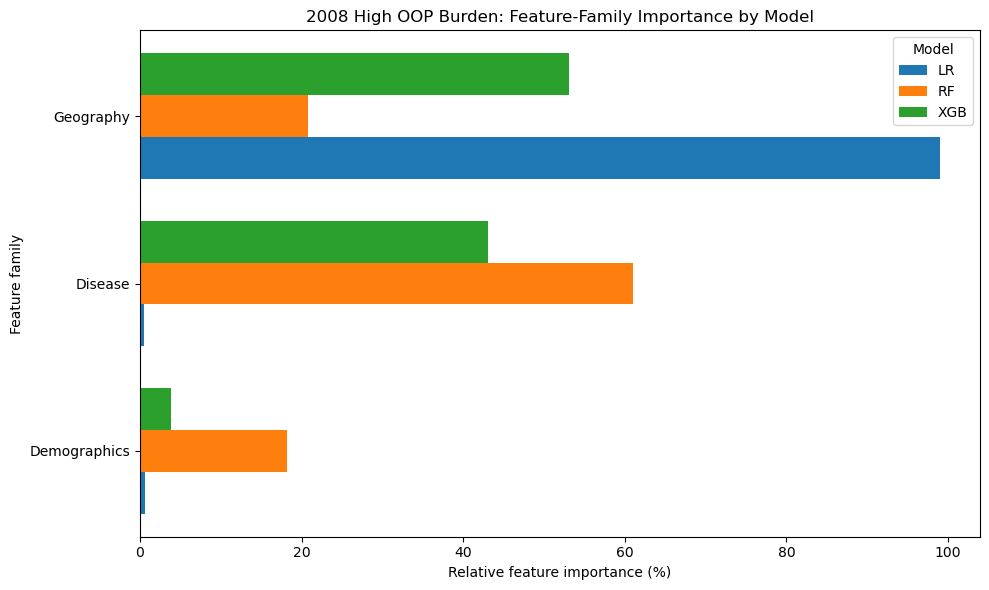

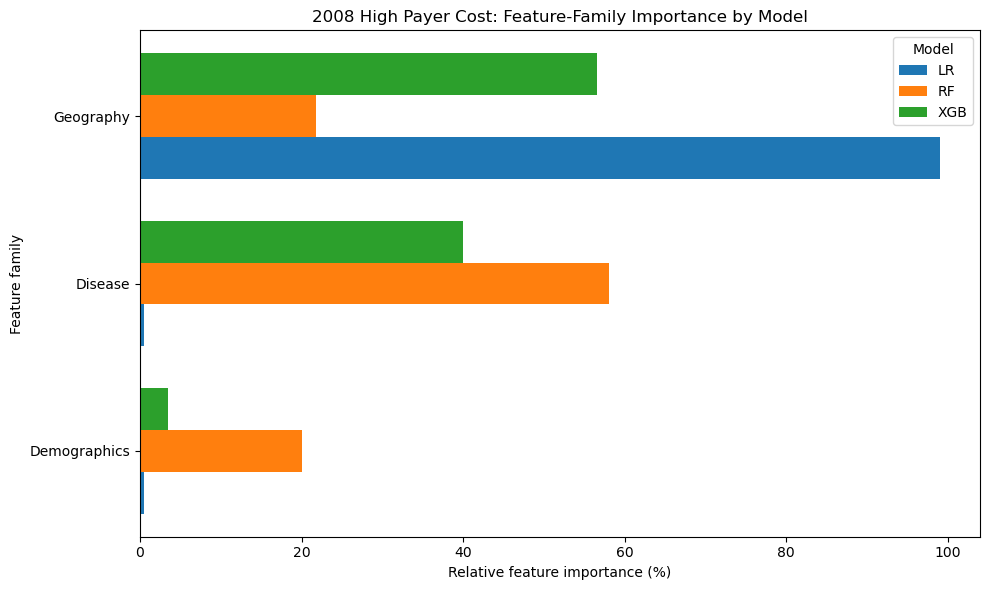

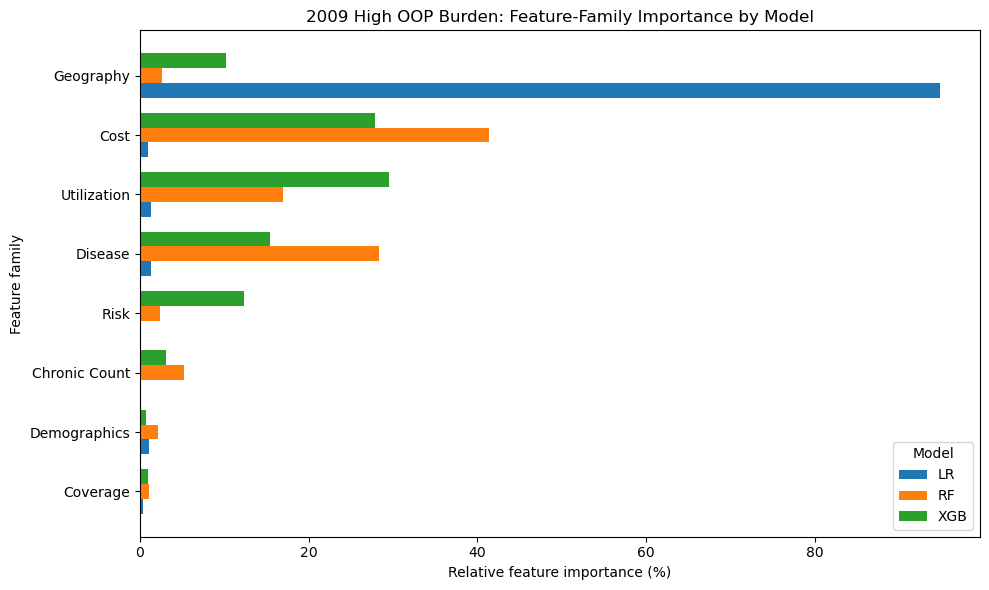

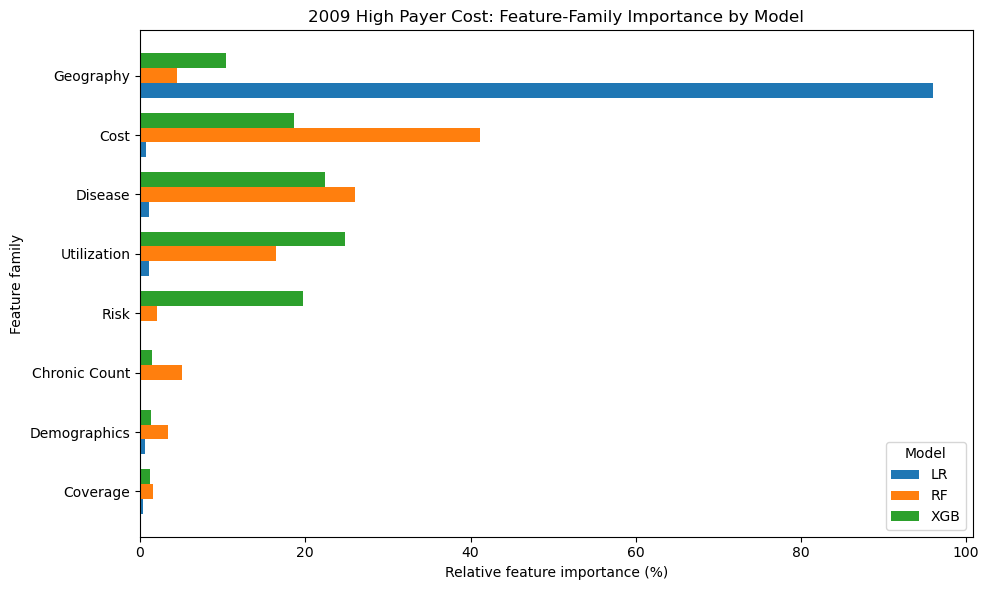

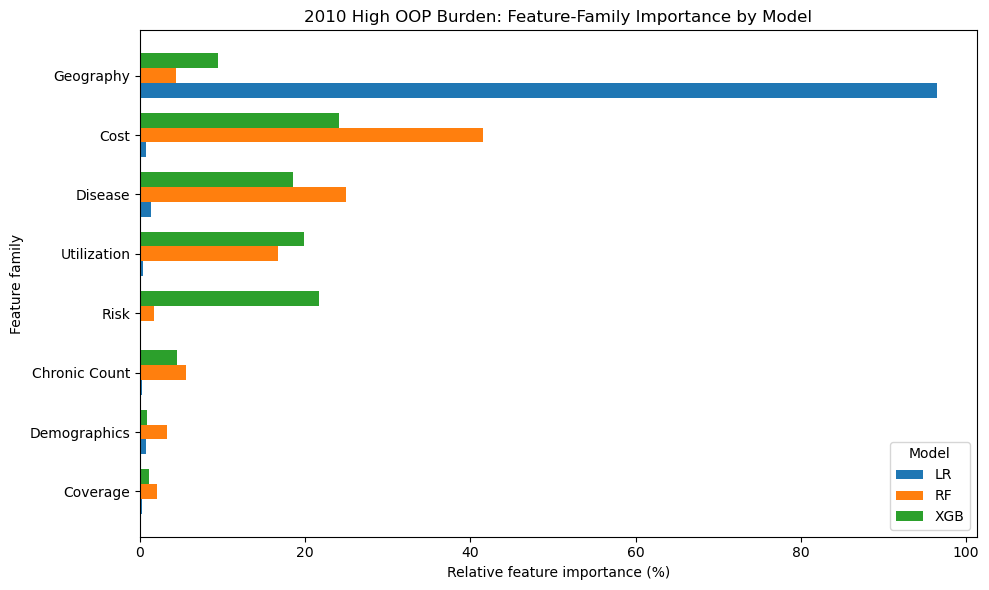

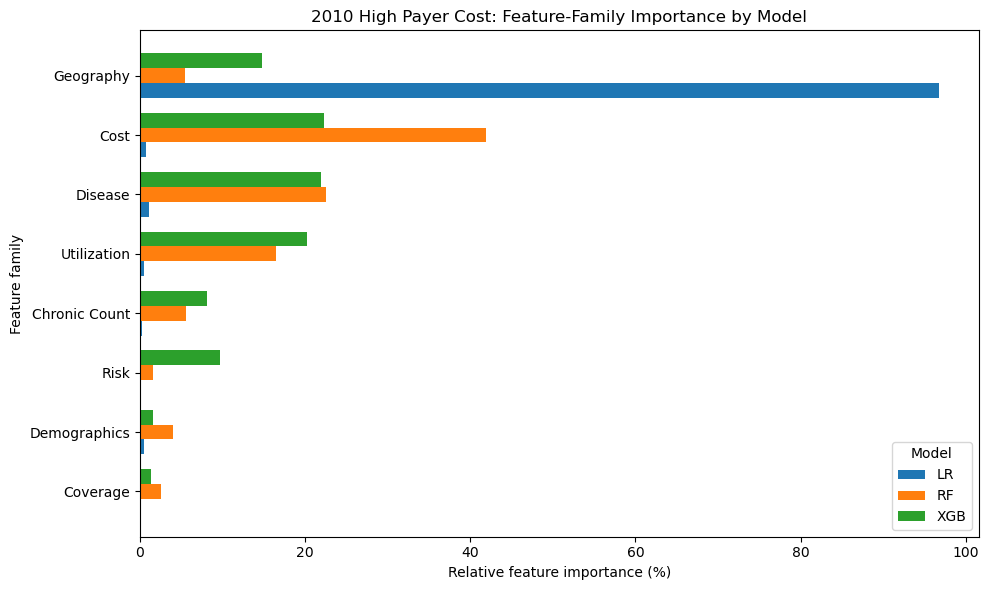

In [35]:
os.makedirs("results/figures", exist_ok=True)

for (year, target), comparison in comparisons.items():
    fig = plot_family_comparison(comparison, year, target, save_path=f"results/figures/{year}_{target}_family_comparison.png")
    plt.show()
    plt.close(fig)

Logistic regression exhibited highly concentrated feature-family importance, with geographic variables accounting for the overwhelming majority of model importance across years and prediction targets. Random forest shifted toward clinically and utilization-relevant information, consistently emphasizing disease burden, prior costs, and healthcare utilization while assigning relatively little importance to geography. XGBoost exhibited the most distributed feature-family profile, combining cost, utilization, disease burden, geography, and—uniquely among the three models—historical high-risk indicators.

Although RF and XGB both relied heavily on prior cost and utilization, their strategies were not identical. RF tended to concentrate importance more heavily in cost and disease families, whereas XGB distributed importance more broadly and increasingly incorporated historical risk indicators.

# **Part 2: SHAP**
**Do these important families consistently push predictions toward higher or lower risk, and how does this mechanism differ among the model choices?**

In [1]:
import shap
import joblib
from src.modeling import *
from src.analyzing import *

In [2]:
lr_2008_oop = joblib.load("results/models/lr_2008_High_OOP_Burden.joblib")
lr_2008_payer = joblib.load("results/models/lr_2008_High_Payer_Cost.joblib")
lr_2009_oop = joblib.load("results/models/lr_2009_High_OOP_Burden.joblib")
lr_2009_payer = joblib.load("results/models/lr_2009_High_Payer_Cost.joblib")
lr_2010_oop = joblib.load("results/models/lr_2010_High_OOP_Burden.joblib")
lr_2010_payer = joblib.load("results/models/lr_2010_High_Payer_Cost.joblib")

rf_2008_oop = joblib.load("results/models/rf_2008_High_OOP_Burden.joblib")
rf_2008_payer = joblib.load("results/models/rf_2008_High_Payer_Cost.joblib")
rf_2009_oop = joblib.load("results/models/rf_2009_High_OOP_Burden.joblib")
rf_2009_payer = joblib.load("results/models/rf_2009_High_Payer_Cost.joblib")
rf_2010_oop = joblib.load("results/models/rf_2010_High_OOP_Burden.joblib")
rf_2010_payer = joblib.load("results/models/rf_2010_High_Payer_Cost.joblib")

xgb_2008_oop = joblib.load("results/models/xgb_2008_High_OOP_Burden.joblib")
xgb_2008_payer = joblib.load("results/models/xgb_2008_High_Payer_Cost.joblib")
xgb_2009_oop = joblib.load("results/models/xgb_2009_High_OOP_Burden.joblib")
xgb_2009_payer = joblib.load("results/models/xgb_2009_High_Payer_Cost.joblib")
xgb_2010_oop = joblib.load("results/models/xgb_2010_High_OOP_Burden.joblib")
xgb_2010_payer = joblib.load("results/models/xgb_2010_High_Payer_Cost.joblib")

In [3]:
models = {
    "lr": {
        (2008, "High_OOP_Burden"): lr_2008_oop,
        (2008, "High_Payer_Cost"): lr_2008_payer,
        (2009, "High_OOP_Burden"): lr_2009_oop,
        (2009, "High_Payer_Cost"): lr_2009_payer,
        (2010, "High_OOP_Burden"): lr_2010_oop,
        (2010, "High_Payer_Cost"): lr_2010_payer,
    },
    "rf": {
        (2008, "High_OOP_Burden"): rf_2008_oop,
        (2008, "High_Payer_Cost"): rf_2008_payer,
        (2009, "High_OOP_Burden"): rf_2009_oop,
        (2009, "High_Payer_Cost"): rf_2009_payer,
        (2010, "High_OOP_Burden"): rf_2010_oop,
        (2010, "High_Payer_Cost"): rf_2010_payer,
    },
    "xgb": {
        (2008, "High_OOP_Burden"): xgb_2008_oop,
        (2008, "High_Payer_Cost"): xgb_2008_payer,
        (2009, "High_OOP_Burden"): xgb_2009_oop,
        (2009, "High_Payer_Cost"): xgb_2009_payer,
        (2010, "High_OOP_Burden"): xgb_2010_oop,
        (2010, "High_Payer_Cost"): xgb_2010_payer,
    }
}

In [4]:
patient = pd.read_csv("cleaned_data/patient_final.csv")

In [5]:
X_tests = {}
y_tests = {}

# In the future, please keep in mind while building the model to keep results, models, and the test sets
for year in [2008, 2009, 2010]:
    X, y = build_features(patient, year)
    X = fix_feature_dtypes(X)
    for target in ["High_OOP_Burden", "High_Payer_Cost"]:
        X_test, y_test = get_test_set(X, y, target)
        X_tests[(year, target)] = X_test
        y_tests[(year, target)] = y_test

In [6]:
X_tests[(2008, "High_OOP_Burden")].shape

(22180, 6)

In [7]:
y_tests[(2008, "High_Payer_Cost")].shape

(22180,)

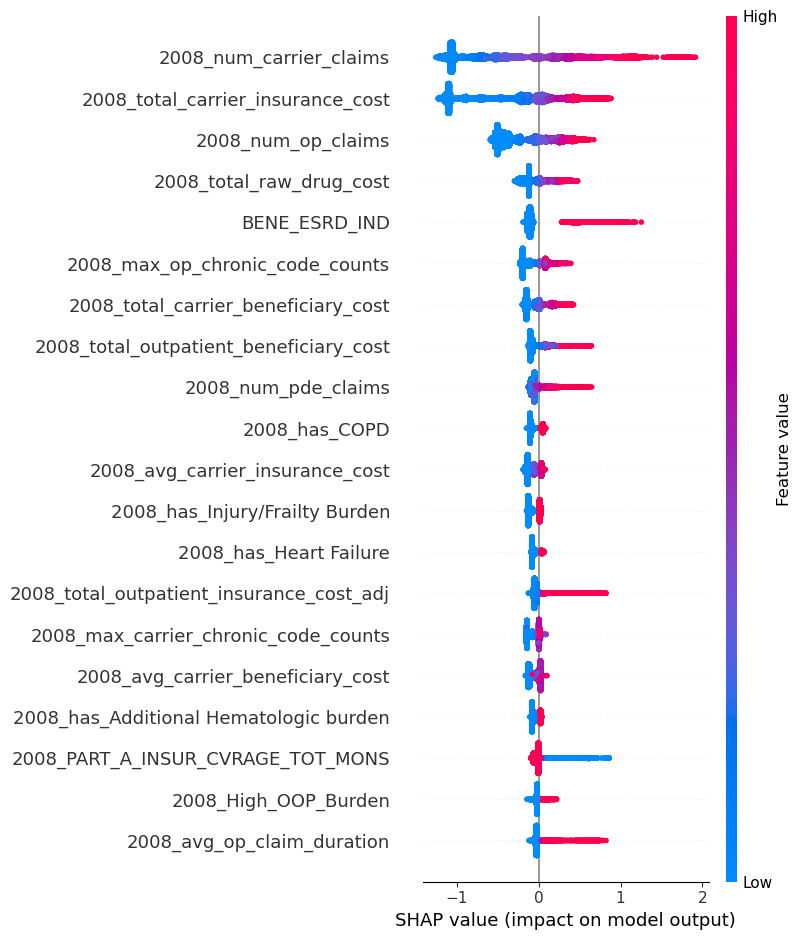

In [8]:
import shap
model = xgb_2009_oop
X_test = X_tests[(2009, "High_OOP_Burden")]

preprocessor = model.named_steps["preprocessor"]
estimator = model.named_steps["model"]
X_test_transformed = preprocessor.transform(X_test)
feature_names = preprocessor.get_feature_names_out()
feature_names = pd.Series(feature_names).str.replace("num__", "", regex=False).str.replace("cat__", "", regex=False).values
explainer = shap.TreeExplainer(estimator)
shap_values = explainer.shap_values(X_test_transformed)
X_test_shap = pd.DataFrame(
    X_test_transformed.toarray()
    if hasattr(X_test_transformed, "toarray")
    else X_test_transformed,
    columns=feature_names,
    index=X_test.index
)
shap.summary_plot(
    shap_values,
    X_test_shap,
    max_display=20
)

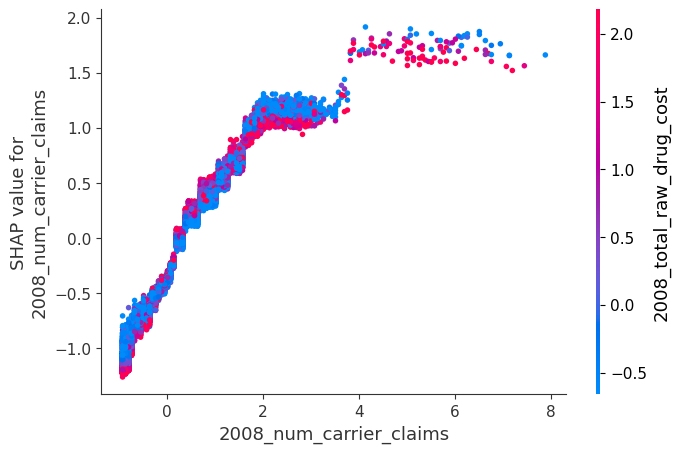

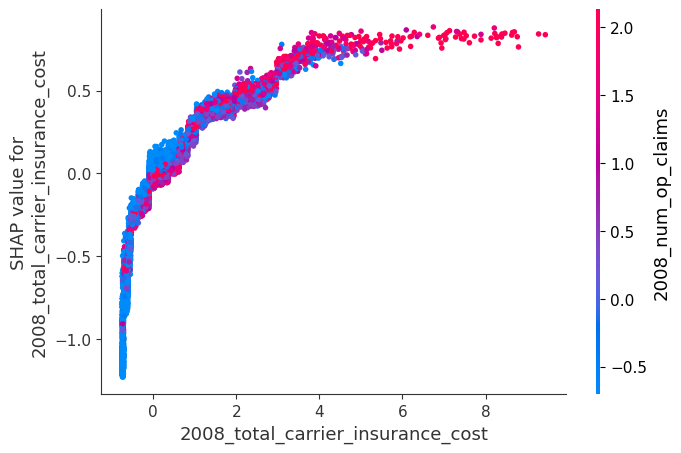

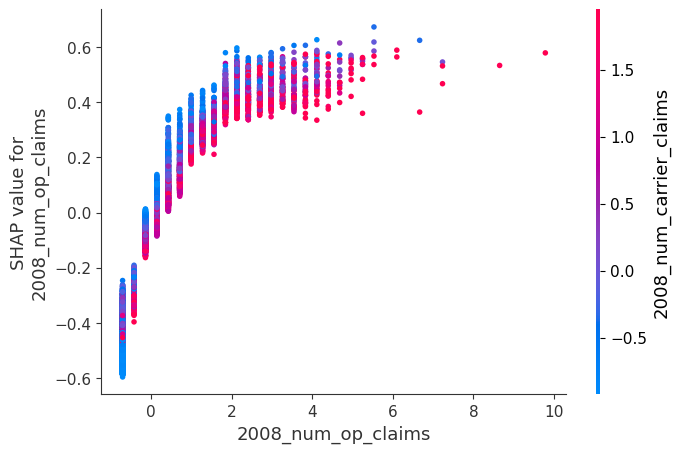

In [9]:
for feature in [
    "2008_num_carrier_claims",
    "2008_total_carrier_insurance_cost",
    "2008_num_op_claims"
]:
    shap.dependence_plot(
        feature,
        shap_values,
        X_test_shap,
        feature_names=feature_names
    )

XGBoost primarily leveraged prior healthcare utilization and cost to identify beneficiaries at risk of high OOP burden. SHAP dependence analysis showed that the effects of carrier claims, carrier insurance costs, and outpatient claims were nonlinear: predicted risk increased rapidly across lower-to-moderate utilization levels before plateauing at higher levels. This suggests that XGBoost captured diminishing marginal predictive value of additional utilization rather than assuming a constant linear relationship.

In [10]:
# Run SHAP for the full xgb model series
plt.close("all")
shap_results = {"xgb": {}}

for model_type, model_group in models.items():
    for (year, target), model in models["xgb"].items():
        print(f"Running SHAP: XGB {year} {target}")
        result = run_shap_analysis(model=model, model_type="xgb", year=year,
                                   target=target, X_test=X_tests[(year, target)],
                                   top_n=3,summary_n=20)
        shap_results["xgb"][(year, target)] = result

Running SHAP: XGB 2008 High_OOP_Burden


/opt/anaconda3/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:2999: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/anaconda3/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3000: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


Running SHAP: XGB 2008 High_Payer_Cost


/opt/anaconda3/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:2999: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/anaconda3/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3000: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


Running SHAP: XGB 2009 High_OOP_Burden
Running SHAP: XGB 2009 High_Payer_Cost
Running SHAP: XGB 2010 High_OOP_Burden
Running SHAP: XGB 2010 High_Payer_Cost
Running SHAP: XGB 2008 High_OOP_Burden


...

/opt/anaconda3/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:2999: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/anaconda3/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3000: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


Running SHAP: XGB 2008 High_Payer_Cost


/opt/anaconda3/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:2999: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/anaconda3/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3000: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


Running SHAP: XGB 2009 High_OOP_Burden
Running SHAP: XGB 2009 High_Payer_Cost
Running SHAP: XGB 2010 High_OOP_Burden


KeyboardInterrupt: 

# Checklist 3: threshold analysis
* given the predictions, where should one draw the line between high-risk and low-risk?
* Investigate the precision-recall tradeoff to decide how we shall operationalize the predictions

# Checklist 4: integrate EDA and modeling findings
* connect the descriptive and predictive findings to determine whether patterns observed in claims data translate into meaningful predictive signals

# **Part 3: Threshold analysis**